# Static Preprocessing 

In [ ]:
import pandas as pd
import os
import sys
import json
from pathlib import Path
import matplotlib.pyplot as plt

# Notebook is in notebooks/, so repo root is parent
REPO_ROOT = Path.cwd().parent
SRC_PATH = REPO_ROOT / "src"

# Insert src at the front of sys.path so imports work
sys.path.insert(0, str(SRC_PATH))


In [4]:
import importlib
import preprocessing.static_preprocessing as sp

importlib.reload(sp)

<module 'preprocessing.static_preprocessing' from '/Users/brandonng/Documents/GitHub/ClinicalDigitalTwin/src/preprocessing/static_preprocessing.py'>

In [5]:
from preprocessing.static_preprocessing import load_static_data

# Get repo root relative to the current notebook
repo_root = os.path.abspath(os.path.join(os.getcwd(), ".."))

# Load static preprocessing config
config_path = os.path.join(repo_root, "configs", "static_preprocessing_params.json")
with open(config_path, "r") as f:
    config = json.load(f)

# Set input and output directories
in_dir = os.path.join(repo_root, config["paths"]["in_dir"])

# Pass in_dir as the first argument
hosp_patients_df, hosp_admissions_df, hosp_diagnosis_df, icustays_df, edstays_df, ed_diagnosis_df = load_static_data(in_dir, config)

## Cleaning Hospital Module

### Hospital Admissions

In [6]:
from preprocessing.static_preprocessing import preprocess_admissions

hosp_admissions_df_cleaned = preprocess_admissions(hosp_admissions_df)
hosp_admissions_df_cleaned.head()

,subject_id,hadm_id,hosp_admittime,hosp_dischtime,deathtime,race,edregtime,edouttime
0,10106244,26713233,2147-05-09 10:34:00,2147-05-12 13:43:00,NaT,WHITE,NaT,NaT
1,13700703,20448599,2172-09-25 01:01:00,2172-10-03 13:25:00,NaT,WHITE,2172-09-24 17:38:00,2172-09-25 03:07:00
2,15443666,27961368,2168-12-30 23:30:00,2169-01-05 16:02:00,NaT,BLACK/AFRICAN AMERICAN,2168-12-30 11:19:00,2168-12-31 01:22:00
3,16299919,26977065,2193-05-15 08:37:00,2193-05-17 16:03:00,NaT,BLACK/AFRICAN AMERICAN,2193-05-15 04:36:00,2193-05-15 14:27:00
4,14149715,24191358,2181-10-25 19:37:00,2181-10-29 14:38:00,NaT,WHITE,2181-10-25 08:48:00,2181-10-26 15:18:00


In [7]:
hosp_admissions_df_cleaned.dtypes

subject_id                 int64
hadm_id                    int64
hosp_admittime    datetime64[ns]
hosp_dischtime    datetime64[ns]
deathtime         datetime64[ns]
race              string[python]
edregtime         datetime64[ns]
edouttime         datetime64[ns]
dtype: object

### Hopsital Patient

In [8]:
from preprocessing.static_preprocessing import preprocess_patient

hosp_patients_df_cleaned = preprocess_patient(hosp_patients_df)
hosp_patients_df_cleaned.head()

,subject_id,gender,anchor_age,dod
0,11289691,F,18,NaT
1,11806971,F,18,NaT
2,12107404,F,18,NaT
3,12143996,F,18,NaT
4,13117076,F,18,NaT


In [9]:
hosp_patients_df_cleaned.dtypes

subject_id             int64
gender        string[python]
anchor_age             int64
dod           datetime64[ns]
dtype: object

### Hospital Diagnosis 

In [10]:
hosp_diagnosis_df

,subject_id,hadm_id,seq_num,icd_code,icd_version,long_title
0,10000935,26381316,27,78052,9,"Insomnia, unspecified"
1,10000980,25242409,27,44021,9,Atherosclerosis of native arteries of the extr...
2,10000980,25242409,28,27800,9,"Obesity, unspecified"
3,10000980,25242409,29,V8522,9,"Body Mass Index 26.0-26.9, adult"
4,10000980,25242409,30,72992,9,Nontraumatic hematoma of soft tissue
...,...,...,...,...,...,...
4843782,19994379,27052619,26,T502X5A,10,Adverse effect of carbonic-anhydrase inhibitor...
4843783,19994379,27334101,26,F329,10,"Major depressive disorder, single episode, uns..."
4843784,19995012,26194582,26,K580,10,Irritable bowel syndrome with diarrhea
4843785,19997473,27787494,26,Y92230,10,Patient room in hospital as the place of occur...


In [11]:
from preprocessing.static_preprocessing import clean_diagnosis_data

hosp_diagnosis_df_cleaned = clean_diagnosis_data(hosp_diagnosis_df, 'hosp')
hosp_diagnosis_df_cleaned.head()


,subject_id,hadm_id,hosp_icd_codes_diagnosis,hosp_diagnosis
0,10000032,22595853,"[5723, 78959, 5715, 07070, 496, 29680, 30981, ...","[Portal hypertension, Other ascites, Cirrhosis..."
1,10000032,22841357,"[07071, 78959, 2875, 2761, 496, 5715, V08, 3051]",[Unspecified viral hepatitis C with hepatic co...
2,10000032,25742920,"[07054, 78959, V462, 5715, 2767, 2761, 496, V0...",[Chronic hepatitis C without mention of hepati...
3,10000032,29079034,"[45829, 07044, 7994, 2761, 78959, 2767, 3051, ...","[Other iatrogenic hypotension, Chronic hepatit..."
4,10000117,22927623,"[R1310, R0989, K31819, K219, K449, F419, I341,...","[Dysphagia, unspecified, Other specified sympt..."


In [12]:
hosp_diagnosis_df_cleaned.dtypes

subject_id                   int64
hadm_id                      int64
hosp_icd_codes_diagnosis    object
hosp_diagnosis              object
dtype: object

## ICU 

### ICU Stays

In [13]:
icustays_df.head()

,subject_id,hadm_id,stay_id,first_careunit,last_careunit,intime,outtime,los
0,10270644,20019675,35548343,PACU,PACU,2159-12-03 16:20:31,2159-12-08 17:28:42,5.047350
1,10368426,21588639,39194905,PACU,PACU,2164-12-30 13:29:21,2164-12-30 14:00:38,0.021725
2,10640410,25898987,34344828,PACU,PACU,2112-02-03 12:55:23,2112-02-08 15:14:54,5.096887
3,10691194,24438843,37799251,PACU,PACU,2147-06-01 17:38:48,2147-06-01 17:58:44,0.013843
4,11162329,26304963,39444424,PACU,PACU,2137-06-11 19:49:23,2137-06-12 14:54:47,0.795417


In [14]:
from preprocessing.static_preprocessing import preprocess_icustays

icustays_df_agg = preprocess_icustays(icustays_df)
icustays_df_agg.head()

,subject_id,hadm_id,icu_stay_id,icu_intime,icu_outtime,icu_count
0,10270644,20019675,[35548343],[2159-12-03 16:20:31],[2159-12-08 17:28:42],1
1,10368426,21588639,"[39194905, 34185188, 38171960]","[2164-12-30 13:29:21, 2164-12-30 14:19:20, 216...","[2164-12-30 14:00:38, 2164-12-31 17:44:11, 216...",3
2,10640410,25898987,"[34344828, 35065956]","[2112-02-03 12:55:23, 2112-02-08 15:57:23]","[2112-02-08 15:14:54, 2112-02-09 15:49:20]",2
3,10691194,24438843,"[37799251, 34379928, 33563673]","[2147-06-01 17:38:48, 2147-06-01 18:24:56, 214...","[2147-06-01 17:58:44, 2147-06-04 22:50:23, 214...",3
4,11162329,26304963,"[39444424, 37586359]","[2137-06-11 19:49:23, 2137-06-05 22:39:12]","[2137-06-12 14:54:47, 2137-06-09 00:23:32]",2


In [15]:
icustays_df_agg.dtypes

subject_id      int64
hadm_id         int64
icu_stay_id    object
icu_intime     object
icu_outtime    object
icu_count       int64
dtype: object

## Emergency Department
### ED Stays

In [16]:
edstays_df.head()

,subject_id,hadm_id,stay_id,intime,outtime,gender,race,arrival_transport,disposition
0,10049341,20677333.0,34255415,2171-04-07 17:48:00,2171-04-08 09:31:00,F,ASIAN,WALK IN,HOME
1,10049341,NaN,35767475,2170-08-29 18:20:00,2170-08-29 22:46:00,F,ASIAN,WALK IN,HOME
2,10049341,NaN,36382949,2171-11-19 20:09:00,2171-11-20 00:03:00,F,ASIAN,WALK IN,HOME
3,10049341,NaN,36490047,2174-11-29 19:39:00,2174-11-30 00:49:00,F,ASIAN,WALK IN,HOME
4,10049341,NaN,37283116,2174-01-26 20:10:00,2174-01-27 00:34:00,F,ASIAN,WALK IN,HOME


In [17]:
from preprocessing.static_preprocessing import preprocess_edstays

edstays_df_cleaned = preprocess_edstays(edstays_df)
edstays_df_cleaned.head()

,subject_id,hadm_id,ed_stay_id,ed_intime,ed_outtime,ed_gender,ed_race
0,10049341,20677333.0,34255415,2171-04-07 17:48:00,2171-04-08 09:31:00,F,ASIAN
1,10049341,NaN,35767475,2170-08-29 18:20:00,2170-08-29 22:46:00,F,ASIAN
2,10049341,NaN,36382949,2171-11-19 20:09:00,2171-11-20 00:03:00,F,ASIAN
3,10049341,NaN,36490047,2174-11-29 19:39:00,2174-11-30 00:49:00,F,ASIAN
4,10049341,NaN,37283116,2174-01-26 20:10:00,2174-01-27 00:34:00,F,ASIAN


In [18]:
edstays_df_cleaned.dtypes

subject_id             int64
hadm_id              float64
ed_stay_id             int64
ed_intime     datetime64[ns]
ed_outtime    datetime64[ns]
ed_gender     string[python]
ed_race       string[python]
dtype: object

### ED Diagnosis

In [19]:
ed_diagnosis_df.head()

,subject_id,stay_id,seq_num,icd_code,icd_version,icd_title
0,16253470,37248432,1,035,9,ERYSIPELAS
1,10396349,36517744,1,042,9,HIV DISEASE
2,10429665,38305760,1,042,9,HIV DISEASE
3,10446182,31712472,1,042,9,HIV DISEASE
4,11053554,34764404,1,042,9,HIV DISEASE


In [20]:
ed_diagnosis_df_cleaned = clean_diagnosis_data(ed_diagnosis_df, 'ed')
ed_diagnosis_df_cleaned.head()

,subject_id,ed_stay_id,ed_icd_codes_diagnosis,ed_diagnosis
0,10000032,32952584,"[4589, 07070, V08]","[HYPOTENSION NOS, UNSPECIFIED VIRAL HEPATITIS ..."
1,10000032,33258284,"[5728, 78959, 07070, V08]","[OTH SEQUELA, CHR LIV DIS, OTHER ASCITES, UNSP..."
2,10000032,35968195,"[5715, 78900, V08]","[CIRRHOSIS OF LIVER NOS, ABDOMINAL PAIN UNSPEC..."
3,10000032,38112554,"[78959, 07070, 5715, V08]","[OTHER ASCITES, UNSPECIFIED VIRAL HEPATITIS C ..."
4,10000032,39399961,"[78097, 34830]","[ALTERED MENTAL STATUS , ENCEPHALOPATHY, UNSPE..."


## Merge Hospital, ICU, and ED Data

In [21]:
from preprocessing.static_preprocessing import merge_hosp_to_ed

static_master_df = merge_hosp_to_ed(hosp_admissions_df_cleaned, hosp_patients_df_cleaned, 
                            hosp_diagnosis_df_cleaned, icustays_df_agg, 
                            edstays_df_cleaned, ed_diagnosis_df_cleaned)

print(static_master_df.shape)
static_master_df.head(5)

(494231, 23)


,subject_id,hadm_id,ed_stay_id,ed_intime,ed_outtime,ed_gender,ed_race,ed_icd_codes_diagnosis,ed_diagnosis,hosp_admittime,...,edouttime,gender,anchor_age,death_time,hosp_icd_codes_diagnosis,hosp_diagnosis,icu_stay_id,icu_intime,icu_outtime,icu_count
0,10000032,22595853.0,33258284.0,2180-05-06 19:17:00,2180-05-06 23:30:00,F,WHITE,"[5728, 78959, 07070, V08]","[OTH SEQUELA, CHR LIV DIS, OTHER ASCITES, UNSP...",2180-05-06 22:23:00,...,2180-05-06 23:30:00,F,52.0,2180-09-09,"[5723, 78959, 5715, 07070, 496, 29680, 30981, ...","[Portal hypertension, Other ascites, Cirrhosis...",NaN,NaN,NaN,NaN
1,10000032,22841357.0,38112554.0,2180-06-26 15:54:00,2180-06-26 21:31:00,F,WHITE,"[78959, 07070, 5715, V08]","[OTHER ASCITES, UNSPECIFIED VIRAL HEPATITIS C ...",2180-06-26 18:27:00,...,2180-06-26 21:31:00,F,52.0,2180-09-09,"[07071, 78959, 2875, 2761, 496, 5715, V08, 3051]",[Unspecified viral hepatitis C with hepatic co...,NaN,NaN,NaN,NaN
2,10000032,25742920.0,35968195.0,2180-08-05 20:58:00,2180-08-06 01:44:00,F,WHITE,"[5715, 78900, V08]","[CIRRHOSIS OF LIVER NOS, ABDOMINAL PAIN UNSPEC...",2180-08-05 23:44:00,...,2180-08-06 01:44:00,F,52.0,2180-09-09,"[07054, 78959, V462, 5715, 2767, 2761, 496, V0...",[Chronic hepatitis C without mention of hepati...,NaN,NaN,NaN,NaN
4,10000032,29079034.0,39399961.0,2180-07-23 05:54:00,2180-07-23 14:00:00,F,WHITE,"[78097, 34830]","[ALTERED MENTAL STATUS , ENCEPHALOPATHY, UNSPE...",2180-07-23 12:35:00,...,2180-07-23 14:00:00,F,52.0,2180-09-09,"[45829, 07044, 7994, 2761, 78959, 2767, 3051, ...","[Other iatrogenic hypotension, Chronic hepatit...",[39553978],[2180-07-23 14:00:00],[2180-07-23 23:50:47],1.0
6,10000117,27988844.0,33176849.0,2183-09-18 08:41:00,2183-09-18 20:20:00,F,WHITE,"[S72092A, W1830XA]","[Oth fracture of head and neck of left femur, ...",2183-09-18 18:10:00,...,2183-09-18 20:20:00,F,48.0,NaT,"[S72012A, W010XXA, Y93K1, Y92480, K219, E7800,...",[Unspecified intracapsular fracture of left fe...,NaN,NaN,NaN,NaN


In [22]:
# Check for duplicates
duplicates = static_master_df.duplicated(subset=['subject_id', 'hadm_id', 'ed_stay_id'], keep=False)

num_duplicates = duplicates.sum()
print(f"Number of non-unique [subject_id, hadm_id, ed_stay_id] pairs: {num_duplicates}")

Number of non-unique [subject_id, hadm_id, ed_stay_id] pairs: 0


In [23]:
missing_ed_times = static_master_df[
    static_master_df['edregtime'].notna() &
    static_master_df['edouttime'].notna() &
    (static_master_df['ed_intime'].isna() | static_master_df['ed_outtime'].isna())
]

# Number of affected rows
print(f"Hospital visits not from ED visit: {len(missing_ed_times)}")

# Optional: show the first few problematic rows
missing_ed_times[['subject_id','hadm_id','edregtime','edouttime','ed_intime','ed_outtime']].head()

Hospital visits not from ED visit: 111370


,subject_id,hadm_id,edregtime,edouttime,ed_intime,ed_outtime
11,10000635,20642640.0,2143-12-23 07:43:00,2143-12-24 12:52:00,NaT,NaT
16,10000826,20032235.0,2146-12-05 11:09:00,2146-12-05 20:54:00,NaT,NaT
18,10000826,28289260.0,2146-12-30 17:06:00,2146-12-31 02:10:00,NaT,NaT
21,10000935,24955974.0,2183-11-07 01:05:00,2183-11-07 11:19:00,NaT,NaT
24,10000935,29541074.0,2183-10-28 03:30:00,2183-10-28 10:39:00,NaT,NaT


In [24]:
missing_ed_times = static_master_df[
    (static_master_df['ed_intime'].notna()) &
    (static_master_df['ed_outtime'].notna()) &
    (
        static_master_df['edregtime'].isna() |
        static_master_df['edouttime'].isna()
    )
]

# Number of affected rows
print(f"ED visits that aren't admitted into the hospital: {len(missing_ed_times)}")

# Optional: show the first few problematic rows
missing_ed_times[['subject_id','hadm_id','edregtime','edouttime','ed_intime','ed_outtime']]

ED visits that aren't admitted into the hospital: 133982


,subject_id,hadm_id,edregtime,edouttime,ed_intime,ed_outtime
7,10000117,NaN,NaT,NaT,2183-07-17 10:30:00,2183-07-17 11:31:00
8,10000285,NaN,NaT,NaT,2161-11-08 14:19:00,2161-11-08 21:06:00
9,10000285,NaN,NaT,NaT,2159-11-26 14:22:00,2159-11-26 19:17:00
13,10000635,NaN,NaT,NaT,2138-09-29 10:54:00,2138-09-29 16:53:00
14,10000635,NaN,NaT,NaT,2141-08-15 11:32:00,2141-08-15 17:06:00
...,...,...,...,...,...,...
530304,19998496,NaN,NaT,NaT,2169-07-21 20:58:00,2169-07-22 00:56:00
530305,19998496,NaN,NaT,NaT,2168-07-24 22:52:00,2168-07-25 02:24:00
530306,19998496,NaN,NaT,NaT,2169-08-03 19:03:00,2169-08-03 23:49:00
530333,19999145,NaN,NaT,NaT,2185-05-24 23:37:00,2185-05-25 05:43:00


In [25]:
# Check rows where subject_id and hadm_id exist, but ed_intime != edregtime
mismatched_ed_times = static_master_df[
    static_master_df['subject_id'].notna() &
    static_master_df['hadm_id'].notna() &
    static_master_df['ed_intime'].notna() &
    static_master_df['edregtime'].notna() &
    (static_master_df['ed_intime'] != static_master_df['edregtime'])
]

print(f"Rows with mismatched ed_intime and edregtime: {len(mismatched_ed_times)}")

# Optional: inspect
mismatched_ed_times[['subject_id','hadm_id', 'edregtime','ed_intime','edouttime', 'ed_outtime']].head(5)


Rows with mismatched ed_intime and edregtime: 0


,subject_id,hadm_id,edregtime,ed_intime,edouttime,ed_outtime


In [26]:
# check for duplicate subject_id and hadm_id for hosp matching with ed
duplicates = static_master_df.duplicated(subset=['subject_id', 'hadm_id'], keep=False)

# deal with ed-only encounters where hadm_id would be NaN
hosp_encounter_duplicates = static_master_df[(duplicates) & (static_master_df['hadm_id'].notna())].head(5)

print(f"Total duplicate rows: {hosp_encounter_duplicates.shape[0]}")

Total duplicate rows: 0


In [27]:
# check for duplicate subject_id and ed_stay_id for hosp matching with ed
duplicates = static_master_df.duplicated(subset=['subject_id', 'ed_stay_id'], keep=False)

# deal with hosp-only encounters where hadm_id would be NaN
ed_encounter_duplicates = static_master_df[(duplicates) & (static_master_df['ed_stay_id'].notna())].head(5)

print(f"Total duplicate rows: {ed_encounter_duplicates.shape[0]}")


Total duplicate rows: 0


In [28]:
static_master_df[['subject_id','hadm_id','hosp_admittime', 'hosp_dischtime', 'edregtime','edouttime', 'ed_intime','ed_outtime']].head(10)

,subject_id,hadm_id,hosp_admittime,hosp_dischtime,edregtime,edouttime,ed_intime,ed_outtime
0,10000032,22595853.0,2180-05-06 22:23:00,2180-05-07 17:15:00,2180-05-06 19:17:00,2180-05-06 23:30:00,2180-05-06 19:17:00,2180-05-06 23:30:00
1,10000032,22841357.0,2180-06-26 18:27:00,2180-06-27 18:49:00,2180-06-26 15:54:00,2180-06-26 21:31:00,2180-06-26 15:54:00,2180-06-26 21:31:00
2,10000032,25742920.0,2180-08-05 23:44:00,2180-08-07 17:50:00,2180-08-05 20:58:00,2180-08-06 01:44:00,2180-08-05 20:58:00,2180-08-06 01:44:00
4,10000032,29079034.0,2180-07-23 12:35:00,2180-07-25 17:55:00,2180-07-23 05:54:00,2180-07-23 14:00:00,2180-07-23 05:54:00,2180-07-23 14:00:00
6,10000117,27988844.0,2183-09-18 18:10:00,2183-09-21 16:30:00,2183-09-18 08:41:00,2183-09-18 20:20:00,2183-09-18 08:41:00,2183-09-18 20:20:00
7,10000117,NaN,NaT,NaT,NaT,NaT,2183-07-17 10:30:00,2183-07-17 11:31:00
8,10000285,NaN,NaT,NaT,NaT,NaT,2161-11-08 14:19:00,2161-11-08 21:06:00
9,10000285,NaN,NaT,NaT,NaT,NaT,2159-11-26 14:22:00,2159-11-26 19:17:00
10,10000560,28979390.0,2189-10-15 10:30:00,2189-10-17 15:00:00,NaT,NaT,NaT,NaT
11,10000635,20642640.0,2143-12-23 14:55:00,2143-12-24 12:52:00,2143-12-23 07:43:00,2143-12-24 12:52:00,NaT,NaT


In [29]:
from preprocessing.static_preprocessing import clean_master_df

clinical_encounter_df = clean_master_df(static_master_df)
print(clinical_encounter_df.shape)
clinical_encounter_df.head(5)

(494231, 17)


,subject_id,hadm_id,ed_stay_id,ed_intime,ed_outtime,hosp_admittime,hosp_dischtime,race,gender,anchor_age,death_time,icu_stay_id,icu_intime,icu_outtime,icu_count,diagnosis,icd_codes
0,10000032,22595853.0,33258284.0,2180-05-06 19:17:00,2180-05-06 23:30:00,2180-05-06 22:23:00,2180-05-07 17:15:00,WHITE,F,52.0,2180-09-09,NaN,NaN,NaN,NaN,"[Portal hypertension, Other ascites, Cirrhosis...","[5723, 78959, 5715, 07070, 496, 29680, 30981, ..."
1,10000032,22841357.0,38112554.0,2180-06-26 15:54:00,2180-06-26 21:31:00,2180-06-26 18:27:00,2180-06-27 18:49:00,WHITE,F,52.0,2180-09-09,NaN,NaN,NaN,NaN,[Unspecified viral hepatitis C with hepatic co...,"[07071, 78959, 2875, 2761, 496, 5715, V08, 3051]"
2,10000032,25742920.0,35968195.0,2180-08-05 20:58:00,2180-08-06 01:44:00,2180-08-05 23:44:00,2180-08-07 17:50:00,WHITE,F,52.0,2180-09-09,NaN,NaN,NaN,NaN,[Chronic hepatitis C without mention of hepati...,"[07054, 78959, V462, 5715, 2767, 2761, 496, V0..."
4,10000032,29079034.0,39399961.0,2180-07-23 05:54:00,2180-07-23 14:00:00,2180-07-23 12:35:00,2180-07-25 17:55:00,WHITE,F,52.0,2180-09-09,[39553978],[2180-07-23 14:00:00],[2180-07-23 23:50:47],1.0,"[Other iatrogenic hypotension, Chronic hepatit...","[45829, 07044, 7994, 2761, 78959, 2767, 3051, ..."
6,10000117,27988844.0,33176849.0,2183-09-18 08:41:00,2183-09-18 20:20:00,2183-09-18 18:10:00,2183-09-21 16:30:00,WHITE,F,48.0,NaT,NaN,NaN,NaN,NaN,[Unspecified intracapsular fracture of left fe...,"[S72012A, W010XXA, Y93K1, Y92480, K219, E7800,..."


In [30]:
clinical_encounter_df.columns

Index(['subject_id', 'hadm_id', 'ed_stay_id', 'ed_intime', 'ed_outtime',
       'hosp_admittime', 'hosp_dischtime', 'race', 'gender', 'anchor_age',
       'death_time', 'icu_stay_id', 'icu_intime', 'icu_outtime', 'icu_count',
       'diagnosis', 'icd_codes'],
      dtype='object')

In [31]:
print(f'Hospital stays with ICU transfers: {clinical_encounter_df[clinical_encounter_df['icu_count'] > 0]['hadm_id'].nunique()}')

Hospital stays with ICU transfers: 56698


In [40]:
print(f'Checking ED duplicates: {clinical_encounter_df['ed_stay_id'].count() != clinical_encounter_df['ed_stay_id'].nunique()}')

print(f'Number of ED encounters: {clinical_encounter_df['ed_stay_id'].nunique()}, ({clinical_encounter_df['ed_stay_id'].nunique()/clinical_encounter_df.shape[0] * 100 :.2f}%)')

Checking ED duplicates: False
Number of ED encounters: 265702, (53.76%)


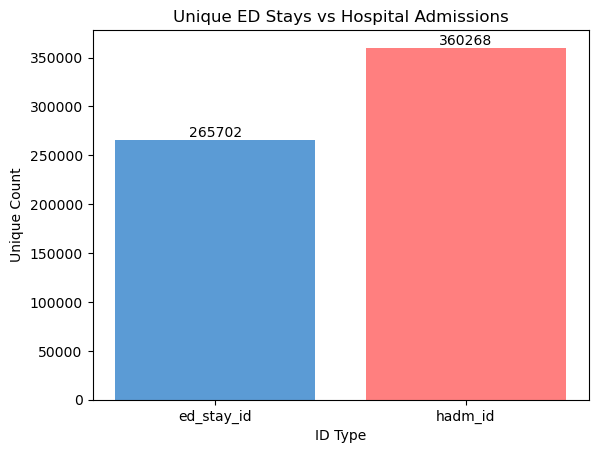

In [50]:
import matplotlib.pyplot as plt

unique_counts = clinical_encounter_df[['ed_stay_id', 'hadm_id']].nunique()
bars = plt.bar(unique_counts.index, unique_counts.values, color=['#5B9BD5', '#FF7F7F'] )

# Add count labels on top of bars
for i, bar in enumerate(bars):
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height,
             f'{int(unique_counts.values[i])}',
             ha='center', va='bottom', fontsize=10)

plt.xlabel('ID Type')
plt.ylabel('Unique Count')
plt.title('Unique ED Stays vs Hospital Admissions')
plt.show()